<a href="https://colab.research.google.com/github/JiyaKakadiya/Jiya-Kakadiya/blob/main/Predictive_Analytics_Model_Using_Historical_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     STAGE 1: HISTORICAL DATA CLEANING & PREPROCESSING   

Processed 48 months of continuous historical sales data.

             STAGE 2: TIME-SERIES FEATURE ENGINEERING    

Training set window: 36 months
Testing/Evaluation evaluation window: 12 months

         STAGE 3: MODEL TRAINING & ACCURACY EVALUATION  

--- Model Accuracy Summary ---
Root Mean Squared Error (RMSE): $14,610.45
Mean Absolute Error (MAE): $10,839.52

         STAGE 4: FORECAST VISUALIZATION GENERATION      



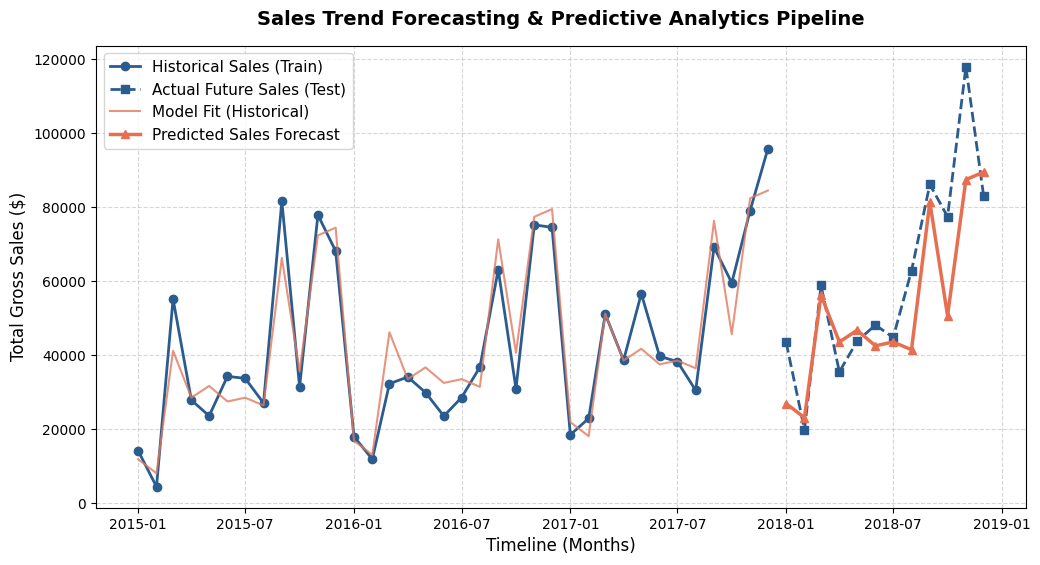

[SUCCESS] Forecast chart exported to your file directory as 'sales_predictions_forecast.png'


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("=========================================================")
print("     STAGE 1: HISTORICAL DATA CLEANING & PREPROCESSING   ")
print("=========================================================\n")

# 1. Load the original transactional dataset
df = pd.read_csv('train.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
df = df.dropna(subset=['Order Date'])

# 2. Resample raw daily transactions into clean continuous Monthly Sales totals
df['YearMonth'] = df['Order Date'].dt.to_period('M')
monthly_data = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_data['YearMonth'] = monthly_data['YearMonth'].dt.to_timestamp()

print(f"Processed {len(monthly_data)} months of continuous historical sales data.")

print("\n=========================================================")
print("             STAGE 2: TIME-SERIES FEATURE ENGINEERING    ")
print("=========================================================\n")

# 1. Create a sequential Time Index to capture the long-term growth trend
monthly_data['Time_Index'] = np.arange(len(monthly_data))

# 2. Extract Month integers to capture recurring yearly seasonality
monthly_data['Month_Num'] = monthly_data['YearMonth'].dt.month

# One-hot encode the months so the linear model understands seasonal shifts
encoded_data = pd.get_dummies(monthly_data, columns=['Month_Num'], drop_first=True)

# Define our predictive variables (X) and target baseline (y)
X = encoded_data.drop(columns=['YearMonth', 'Sales'])
y = encoded_data['Sales']

# 3. Train-Test Split (Hold back the final 12 months to evaluate our model's accuracy)
train_size = len(encoded_data) - 12
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Training set window: {train_size} months")
print(f"Testing/Evaluation evaluation window: {len(X_test)} months")


print("\n=========================================================")
print("         STAGE 3: MODEL TRAINING & ACCURACY EVALUATION  ")
print("=========================================================\n")

# 1. Initialize and fit the Predictive Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 2. Generate predictions across both timelines
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# 3. Calculate scientific accuracy metrics over the test window
rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
mae = mean_absolute_error(y_test, test_predictions)

print(f"--- Model Accuracy Summary ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")


print("\n=========================================================")
print("         STAGE 4: FORECAST VISUALIZATION GENERATION      ")
print("=========================================================\n")

# Structure a clean plotting canvas
plt.figure(figsize=(12, 6))

# Plot actual historical points
plt.plot(monthly_data['YearMonth'][:train_size], y_train, label='Historical Sales (Train)', color='#2b5c8f', linewidth=2, marker='o')
plt.plot(monthly_data['YearMonth'][train_size:], y_test, label='Actual Future Sales (Test)', color='#2b5c8f', linewidth=2, linestyle='--', marker='s')

# Overlay the predictive models guesses
plt.plot(monthly_data['YearMonth'][:train_size], train_predictions, label='Model Fit (Historical)', color='#e07a5f', linewidth=1.5, alpha=0.8)
plt.plot(monthly_data['YearMonth'][train_size:], test_predictions, label='Predicted Sales Forecast', color='#e76f51', linewidth=2.5, marker='^')

# Refine chart presentation
plt.title('Sales Trend Forecasting & Predictive Analytics Pipeline', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline (Months)', fontsize=12)
plt.ylabel('Total Gross Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)

# Export graph as a clean presentation image
plt.savefig('sales_predictions_forecast.png', bbox_inches='tight', dpi=300)
plt.show()
print("[SUCCESS] Forecast chart exported to your file directory as 'sales_predictions_forecast.png'")